# GISAID Discrepancies

## Housekeeping

In [1]:
# Housekeeping

import os
import glob 
import pandas as pd
import xml.etree.ElementTree as ET
import requests
import time
import numpy as np
import dateutil 
from datetime import datetime
from collections import defaultdict 
import matplotlib.pyplot as plt

def partial_isolate(id):

    partial = id.replace("_", "-") # [-1] # If 25_, get the last bit
    partial = partial.replace("-original", "") # If -original suffix, remove
    partial = partial.replace("G", "-0") # If 25G, fix
    digits = partial.split("-")
    # Build partial isolates
    isolate = ""
    # other = ""
    for d in digits:
        # print(d)
        if len(d) == 2 and d.isnumeric(): # The 25 bit
            # isolate = d + "-"
            pass
        if len(d) == 6 and d.isnumeric(): # If it's just digits and not one of those weird isolates
            isolate = d + "-"
        if len(d) == 3 and d.isnumeric():
            isolate = isolate + d
        # elif d.isnumeric() == False: # If it's a weird isolate
        #     other = d + "-"
        # else: 
        #     other = partial 
    # Now add to list to check in Andersen files without doing wild for loops
    if len(isolate) == 10: # If this is a correctly formatted isolate
        # isolates.append(isolate)
        # All headers are followed by sequences
        partial_isolate = isolate
    else: # If this is some other isolate
        partial_isolate = partial

    return partial_isolate

In [2]:
os.chdir("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/GISAID/downloads/2021-11-01--2025-06-13_Antarctica_North_America_South_America/")

gisaid_jun_13_2025 = pd.DataFrame()

for dirpath, dirs, files in os.walk("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/GISAID/downloads/2021-11-01--2025-06-13_Antarctica_North_America_South_America/"):
    for file in files:
        file_name = os.path.join(dirpath, file)
        if ".xls" in file_name:
            df = pd.read_excel(file_name)
            gisaid_jun_13_2025 = pd.concat([gisaid_jun_13_2025, df])
    break 

print(gisaid_jun_13_2025)

gisaid_jun_13_2025["Submission_Date"] = gisaid_jun_13_2025["Submission_Date"].apply(lambda x: dateutil.parser.parse(x))
gisaid_jun_13_2025["Collection_Date"] = gisaid_jun_13_2025["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

# gisaid_jun_13_2025 = gisaid_jun_13_2025[(gisaid_jun_13_2025["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (gisaid_jun_13_2025["Submission_Date"] <= dateutil.parser.parse("04/14/2025"))]
gisaid_jun_13_2025["Isolate"] = gisaid_jun_13_2025["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# gisaid_feb_20_2026["Isolate_gisaid"] = gisaid_feb_20_2026["Isolate"]
# gisaid_feb_20_2026["Publication"]
gisaid_jun_13_2025["Geo_Location_Specific"] = gisaid_jun_13_2025["Location"].apply(lambda x: x.split(" / ")[-1] if "United States" in x else x.split(" / ")[1] if len(x.split(" / ")) > 1 else x)
gisaid_jun_13_2025["Partial"] = gisaid_jun_13_2025["Isolate"].apply(partial_isolate)
print(gisaid_jun_13_2025.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])

            Isolate_Id                                     PB2 Segment_Id  \
0     EPI_ISL_16102933  EPI2243880|PB2_A/goose/Idaho/22-012047-001-ori...   
1     EPI_ISL_11971496  EPI2017172|Seq1 [organism=Influenza A virus](A...   
2     EPI_ISL_16173525        EPI2246894|A/Snow Goose/SK/FAV-0216-06/2022   
3     EPI_ISL_16172175        EPI2246886|A/Snow Goose/SK/FAV-0216-02/2022   
4     EPI_ISL_16171530        EPI2246877|A/Snow Goose/SK/FAV-0216-01/2022   
...                ...                                                ...   
1645  EPI_ISL_19705414  EPI3885044|A/dairy cow/California/001172-001/2...   
1646  EPI_ISL_19705413     EPI3885036|A/dairy cow/USA/001175-001/2025_PB2   
1647  EPI_ISL_19705412     EPI3885028|A/dairy cow/USA/001182-001/2025_PB2   
1648  EPI_ISL_19705411     EPI3885020|A/dairy cow/USA/001182-003/2025_PB2   
1649  EPI_ISL_19705410     EPI3885012|A/dairy cow/USA/000593-001/2025_PB2   

                                         PB1 Segment_Id  \
0     EPI2243881

In [10]:
os.chdir("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/")

gisaid_feb_20_2026 = pd.DataFrame()
for dirpath, dirs, files in os.walk("C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/GISAID/downloads/2021-11-01--2026-02-20_Antarctica_North_America_South_America/"):
    for file in files:
        file_name = os.path.join(dirpath, file)
        if ".xls" in file_name:
            df = pd.read_excel(file_name)
            gisaid_feb_20_2026 = pd.concat([gisaid_feb_20_2026, df])
    break 
# gisaid_apr_14_2025 = pd.read_csv("GISAID_submission_dates_02-14-2022--12-26-2024_accessed_04-14-2025.csv")
genbank_feb_20_2026 = pd.read_csv("NCBI_Virus/downloads/11-01-2021--02-20-2026_Antarctica_North_America_South_America/sequences.csv")
# genbank_apr_14_2025 = pd.read_csv("GenBank_submission_dates_02-14-2022--12-26-2024_accessed_04-14-2025.csv")
genbank_jun_13_2025 = pd.read_csv("NCBI_Virus/downloads/11-01-2021--06-13-2025_Antarctica_North_America_South_America_preprint/sequences.csv")

In [11]:
# gisaid_apr_14_2025["Submission_Date"] = gisaid_apr_14_2025["Submission_Date"].apply(lambda x: dateutil.parser.parse(x))
# gisaid_apr_14_2025["Collection_Date"] = gisaid_apr_14_2025["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

# gisaid_apr_14_2025 = gisaid_apr_14_2025[(gisaid_apr_14_2025["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (gisaid_apr_14_2025["Submission_Date"] <= dateutil.parser.parse("04/14/2025"))]
# gisaid_apr_14_2025["Isolate"] = gisaid_apr_14_2025["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# gisaid_apr_14_2025["Authors"] = gisaid_apr_14_2025["Authors"].apply(lambda x: x.split(", ")[0] if x==x else x)
# print(gisaid_apr_14_2025.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name", "Isolate"]])

In [12]:
gisaid_feb_20_2026["Submission_Date"] = gisaid_feb_20_2026["Submission_Date"].apply(lambda x: dateutil.parser.parse(x))
gisaid_feb_20_2026["Collection_Date"] = gisaid_feb_20_2026["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

gisaid_feb_20_2026 = gisaid_feb_20_2026[(gisaid_feb_20_2026["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (gisaid_feb_20_2026["Submission_Date"] <= dateutil.parser.parse("06/13/2025"))]
gisaid_feb_20_2026["Isolate"] = gisaid_feb_20_2026["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# gisaid_feb_20_2026["Isolate_gisaid"] = gisaid_feb_20_2026["Isolate"]
# gisaid_feb_20_2026["Publication"]
gisaid_feb_20_2026["Geo_Location_Specific"] = gisaid_feb_20_2026["Location"].apply(lambda x: x.split(" / ")[-1] if "United States" in x else x.split(" / ")[1] if len(x.split(" / ")) > 1 else x)
gisaid_feb_20_2026["Partial"] = gisaid_feb_20_2026["Isolate"].apply(partial_isolate)
print(gisaid_feb_20_2026.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])
# print(gisaid_feb_20_2026[gisaid_feb_20_2026["Submission_Date"] > dateutil.parser.parse("01/01/2025")])

     Submission_Date                                       Isolate_Name
770       2022-02-14    A/American wigeon/North Carolina/AH0182517/2022
769       2022-02-14            A/mallard/North Carolina/AH0182886/2022
768       2022-02-14   A/northern pintail/North Carolina/AH0182892/2022
767       2022-02-14            A/gadwall/North Carolina/AH0182894/2022
766       2022-02-14  A/northern shoveler/North Carolina/AH0182913/2022
...              ...                                                ...
3014      2025-06-11                    A/dairy cow/USA/016724-001/2025
3015      2025-06-11                    A/dairy cow/USA/016724-003/2025
3013      2025-06-11                    A/dairy cow/USA/016596-001/2025
3026      2025-06-11             A/dairy cow/California/016317-005/2025
1721      2025-06-12                        A/cat/New York/UIUC-01/2025

[17775 rows x 2 columns]


In [13]:
# genbank_apr_14_2025["Submission_Date"] = genbank_apr_14_2025["Release_Date"].apply(lambda x: dateutil.parser.parse(x))
# genbank_apr_14_2025["Collection_Date"] = genbank_apr_14_2025["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

# genbank_apr_14_2025 = genbank_apr_14_2025[(genbank_apr_14_2025["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (genbank_apr_14_2025["Submission_Date"] <= dateutil.parser.parse("04/14/2025"))]
# genbank_apr_14_2025["Isolate_Name"] = genbank_apr_14_2025["GenBank_Title"].apply(lambda x: x.split("(")[1])
# genbank_apr_14_2025["Isolate"] = genbank_apr_14_2025["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# # genbank_feb_20_2026["Isolate_genbank"] = genbank_feb_20_2026["Isolate"]
# genbank_apr_14_2025["Authors"] = genbank_apr_14_2025["Submitters"].apply(lambda x: x.split(" (")[0])
# print(genbank_apr_14_2025.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])

In [14]:
genbank_jun_13_2025["Submission_Date"] = genbank_jun_13_2025["Release_Date"].apply(lambda x: dateutil.parser.parse(x))
genbank_jun_13_2025["Collection_Date"] = genbank_jun_13_2025["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

# genbank_jun_13_2025 = genbank_jun_13_2025[(genbank_jun_13_2025["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (genbank_jun_13_2025["Submission_Date"] <= dateutil.parser.parse("04/14/2025"))]
genbank_jun_13_2025["Isolate_Name"] = genbank_jun_13_2025["GenBank_Title"].apply(lambda x: x.split("(")[1])
genbank_jun_13_2025["Isolate"] = genbank_jun_13_2025["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# genbank_feb_20_2026["Isolate_genbank"] = genbank_feb_20_2026["Isolate"]
genbank_jun_13_2025["Authors"] = genbank_jun_13_2025["Submitters"].apply(lambda x: x.split(" (")[0])
print(genbank_jun_13_2025.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])

      Submission_Date                                   Isolate_Name
83496      2021-11-01              A/chicken/Veracruz/28159-398/1995
83223      2021-11-01               A/chicken/Guatemala/45511-4/2000
83224      2021-11-01               A/chicken/Guatemala/45511-4/2000
83225      2021-11-01               A/chicken/Guatemala/45511-5/2000
83226      2021-11-01               A/chicken/Guatemala/45511-5/2000
...               ...                                            ...
4          2025-06-01  A/feline/San Bernardino County/297271-24/2024
3          2025-06-01  A/feline/San Bernardino County/297271-24/2024
2          2025-06-01  A/feline/San Bernardino County/297271-24/2024
1          2025-06-01  A/feline/San Bernardino County/297271-24/2024
0          2025-06-01  A/feline/San Bernardino County/297271-24/2024

[83497 rows x 2 columns]


In [ ]:
genbank_feb_20_2026["Submission_Date"] = genbank_feb_20_2026["Release_Date"].apply(lambda x: dateutil.parser.parse(x))
genbank_feb_20_2026["Collection_Date"] = genbank_feb_20_2026["Collection_Date"].apply(lambda x: dateutil.parser.parse(x))

genbank_feb_20_2026 = genbank_feb_20_2026[(genbank_feb_20_2026["Submission_Date"] >= dateutil.parser.parse("11/01/2021")) & (genbank_feb_20_2026["Submission_Date"] <= dateutil.parser.parse("06/13/2025"))]
genbank_feb_20_2026["Isolate_Name"] = genbank_feb_20_2026["GenBank_Title"].apply(lambda x: x.split("(")[1])
genbank_feb_20_2026["Isolate"] = genbank_feb_20_2026["Isolate_Name"].apply(lambda x: x.split("/")[-2])
# genbank_feb_20_2026["Isolate_genbank"] = genbank_feb_20_2026["Isolate"]
# genbank_feb_20_2026["Authors"] = genbank_feb_20_2026["Submitters"] #.apply(lambda x: x.split(" (")[0])
genbank_feb_20_2026["Partial"] = genbank_feb_20_2026["Isolate"].apply(partial_isolate)
genbank_feb_20_2026["Geo_Location_Specific"] = genbank_feb_20_2026["Geo_Location"].apply(lambda x: x.split(": ")[-1] if "USA" not in x else genbank_feb_20_2026[genbank_feb_20_2026["Geo_Location"] == x]["USA"].values[0])
print(genbank_feb_20_2026.sort_values("Submission_Date")[["Submission_Date", "Isolate_Name"]])

In [ ]:
genbank_gisaid_common = genbank_feb_20_2026.merge(gisaid_feb_20_2026, on="Isolate", suffixes=["_genbank", "_gisaid"])
print(genbank_gisaid_common)

       Accession GenBank_RefSeq         Assembly SRA_Accession BioSample  \
0     OP221041.1        GenBank  GCA_039273285.1           NaN       NaN   
1     OP221042.1        GenBank  GCA_039273285.1           NaN       NaN   
2     OP221043.1        GenBank  GCA_039273285.1           NaN       NaN   
3     OP221044.1        GenBank  GCA_039273285.1           NaN       NaN   
4     OP221045.1        GenBank  GCA_039273285.1           NaN       NaN   
...          ...            ...              ...           ...       ...   
9372  PQ809562.1        GenBank  GCA_046439575.1           NaN       NaN   
9373  PQ809563.1        GenBank  GCA_046439575.1           NaN       NaN   
9374  PQ809563.1        GenBank  GCA_046439575.1           NaN       NaN   
9375  PQ809564.1        GenBank  GCA_046439575.1           NaN       NaN   
9376  PQ809564.1        GenBank  GCA_046439575.1           NaN       NaN   

        BioProject      Organism_Name                         Species  \
0      PRJNA80

In [ ]:
genbank_gisaid_uncommon = genbank_feb_20_2026.merge(gisaid_feb_20_2026, on=["Collection_Date", "Submission_Date", "Partial"], suffixes=["_genbank", "_gisaid"])
genbank_gisaid_uncommon["Year"] = genbank_gisaid_uncommon["Collection_Date"].apply(lambda x: x.year)

print((genbank_gisaid_uncommon[genbank_gisaid_uncommon["Year"] == "2025"]))


Empty DataFrame
Columns: [Accession, GenBank_RefSeq, Assembly, SRA_Accession, BioSample, BioProject, Organism_Name, Species, Genus, Family, Genotype_genbank, Isolate_genbank, Segment, GenBank_Title, Length, Nuc_Completeness, Geo_Location, Country, USA, Host_genbank, Tissue_Specimen_Source, Submitters, Organization, Org_location, Publications, Collection_Date, Release_Date, Molecule_type, Submission_Date, Isolate_Name_genbank, Partial, Geo_Location_Specific_genbank, Isolate_Id, PB2 Segment_Id, PB1 Segment_Id, PA Segment_Id, HA Segment_Id, NP Segment_Id, NA Segment_Id, MP Segment_Id, NS Segment_Id, HE Segment_Id, P3 Segment_Id, Isolate_Name_gisaid, Subtype, Genotype_gisaid, Lineage, Clade, Pathogenicity, Passage_History, Location, Host_gisaid, Isolate_Submitter, Submitting_Sample_Id, Publication, Originating_Sample_Id, Note, Update_Date, Antigen_Character, Animal_Vaccin_Product, Adamantanes_Resistance_geno, Oseltamivir_Resistance_geno, Zanamivir_Resistance_geno, Peramivir_Resistance_geno

In [ ]:
gisaid_time = gisaid_jun_13_2025.merge(gisaid_feb_20_2026, on="Isolate_Id", suffixes=["_old", "_new"])
print(gisaid_time)

             Isolate_Id                                 PB2 Segment_Id_old  \
0      EPI_ISL_16102933  EPI2243880|PB2_A/goose/Idaho/22-012047-001-ori...   
1      EPI_ISL_11971496  EPI2017172|Seq1 [organism=Influenza A virus](A...   
2      EPI_ISL_16173525        EPI2246894|A/Snow Goose/SK/FAV-0216-06/2022   
3      EPI_ISL_16172175        EPI2246886|A/Snow Goose/SK/FAV-0216-02/2022   
4      EPI_ISL_16171530        EPI2246877|A/Snow Goose/SK/FAV-0216-01/2022   
...                 ...                                                ...   
12087  EPI_ISL_19736792  EPI3979941|A/bald eagle/Massachusetts/014126-0...   
12088  EPI_ISL_19736786  EPI3979893|A/bald eagle/Virginia/014128-001/20...   
12089  EPI_ISL_19736762  EPI3979701|A/bald eagle/Massachusetts/014126-0...   
12090  EPI_ISL_19736761  EPI3979693|A/bald eagle/Massachusetts/014126-0...   
12091  EPI_ISL_19736759  EPI3979677|A/bald eagle/Massachusetts/014126-0...   

                                      PB1 Segment_Id_old  \
0  

## Differences between GenBank and GISAID

### Isolates

All of the following have the same isolate "root", but different complete isolates. 

Isolate discrepancy examples:
- Sometimes the beginning hyphen in an isolate will be changed to an underscore (24-014001-004 -> 24_014001-004)
- Sometimes an appended "-original" at the end of the isolate will disappear (24-014001-004-original -> 24-014001-004)
- Sometimes the last two digits of a year at the beginning of an isolate will disappear (24-009038-001 -> 009038-001)
- Sometimes a repeated isolate will have the "-repeat2" appendage changed to "-R2" (24-015840-001-original-repeat2 -> 24_015840-001-R2)
- Sometimes, despite the same authors, collection date, location, and host, the isolate IDs are completely different (CEIRR-293 -> TN22-293)

            Isolate_genbank Isolate_gisaid  \
0             24-009038-001     009038-001   
1             24-009038-001     009038-001   
2             24-009038-001     009038-001   
3             24-009038-001     009038-001   
4             24-009038-001     009038-001   
..                      ...            ...   
907  24-031264-004-combined  24-031264-004   
908  24-031264-004-combined  24-031264-004   
909  24-031264-004-combined  24-031264-004   
910  24-031264-004-combined  24-031264-004   
911  24-031264-004-combined  24-031264-004   

                          Isolate_Name_genbank  \
0    A/domestic cat/Montana/24-009038-001/2024   
1    A/domestic cat/Montana/24-009038-001/2024   
2    A/domestic cat/Montana/24-009038-001/2024   
3    A/domestic cat/Montana/24-009038-001/2024   
4    A/domestic cat/Montana/24-009038-001/2024   
..                                         ...   
907       A/pig/OR/24-031264-004-combined/2024   
908       A/pig/OR/24-031264-004-combined/2024 

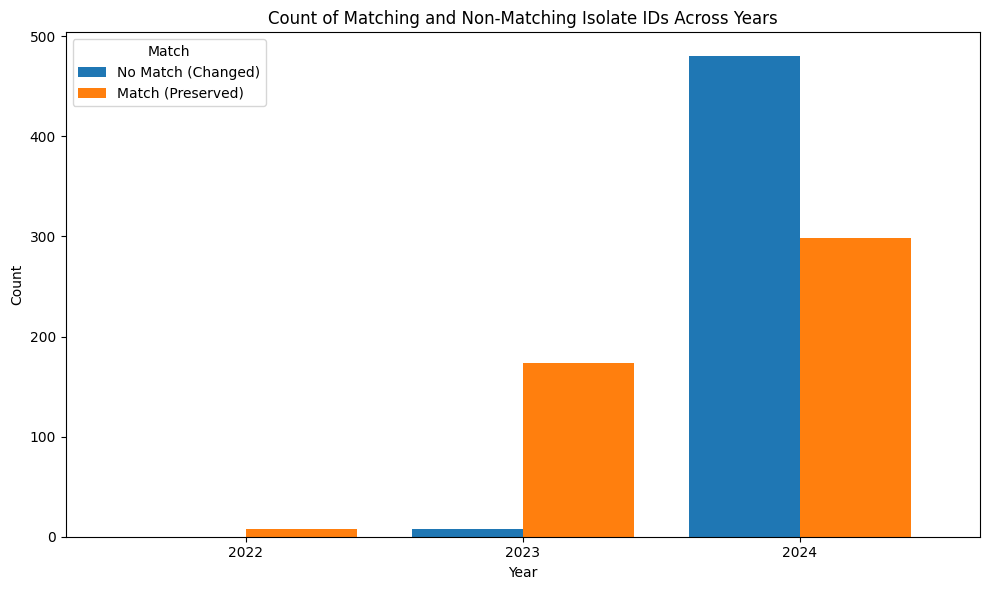

In [ ]:
print(genbank_gisaid_uncommon[genbank_gisaid_uncommon["Isolate_genbank"] != genbank_gisaid_uncommon["Isolate_gisaid"]][["Isolate_genbank", "Isolate_gisaid", "Isolate_Name_genbank", "Isolate_Name_gisaid"]])

genbank_gisaid_uncommon["Match"] = (genbank_gisaid_uncommon["Isolate_genbank"] == genbank_gisaid_uncommon["Isolate_gisaid"])


match_counts = genbank_gisaid_uncommon.groupby(["Year", "Match"]).size().rename('Count').reset_index()
df_plot = match_counts.pivot_table(index='Year', columns='Match', values='Count', fill_value=0)

print(df_plot)

# Plot the grouped bar chart using pandas built-in plot function
ax = df_plot.plot(kind='bar', figsize=(10, 6), width=0.8)

# Customize the plot
plt.title('Count of Matching and Non-Matching Isolate IDs Across Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Match', labels=['No Match (Changed)', 'Match (Preserved)']) # Add a legend with meaningful labels
plt.tight_layout()

# Display the plot
plt.show()

# ax = match_counts.plot(kind='bar', figsize=(10, 6))

# # Customize the plot using matplotlib functions
# plt.title('Number of Identical Isolate IDs Between GenBank and GISAID Across Years')
# plt.xlabel('Year')
# plt.ylabel('Count of Identical Isolate IDs')
# plt.xticks(rotation=45) # Rotate x-axis labels for better readability
# plt.grid(axis='y', linestyle='--')
# plt.tight_layout() # Adjust layout to make room for x-axis labels
# plt.show()

# match_counts = matches.value_counts()

# plt.figure(figsize=(6, 4))

# # Plotting the match counts
# match_counts.plot(kind='bar', color=['green', 'orange'])

# # Adding labels and a title
# plt.title('Count of matching isolate IDs between GenBank and GISAID')
# plt.xlabel('IDs match (True/False)')
# plt.ylabel('Count')
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# # Display the plot
# plt.show()

In [ ]:
print(genbank_gisaid_uncommon[genbank_gisaid_uncommon["Isolate_gisaid"] != genbank_gisaid_uncommon["Isolate_genbank"]][["Isolate_genbank", "Isolate_gisaid", "Isolate_Name_genbank", "Isolate_Name_gisaid"]][:50])

                    Isolate_genbank    Isolate_gisaid  \
0                     24-009038-001        009038-001   
1                     24-009038-001        009038-001   
2                     24-009038-001        009038-001   
3                     24-009038-001        009038-001   
4                     24-009038-001        009038-001   
5                     24-009038-001        009038-001   
6                     24-009038-001        009038-001   
7                     24-009038-001        009038-001   
8                     24-007379-002        007379-002   
9                     24-007379-002        007379-002   
10                    24-007379-002        007379-002   
11                    24-007379-002        007379-002   
12                    24-007379-002        007379-002   
13                    24-007379-002        007379-002   
14                    24-007379-002        007379-002   
15                    24-007379-002        007379-002   
16                    24-008552

### Isolate Names

All of these share isolate IDs, but have different full isolate names. This occurs in about half (2719/4955) of our sample. 

Isolate name discrepancy examples:
- GISAID sometimes cuts off or changes the specific type of animal to a general animal (snow goose -> goose, black vulture -> vulture, mallard -> duck, etc.)
- GISAID sometimes subtly changes the location name (Bio Bio -> Biobio, CHL -> Chile, etc.)
- GISAID sometimes changes the specific location to a more general location (Antofagasta -> Chile, etc.)
- Sometimes the isolate ids between genbank and gisaid are the same, but the isolate names are completely different (A/Missouri/121/2024 has the same isolate id as A/red-shouldered hawk/North Carolina/121/2022, etc.)

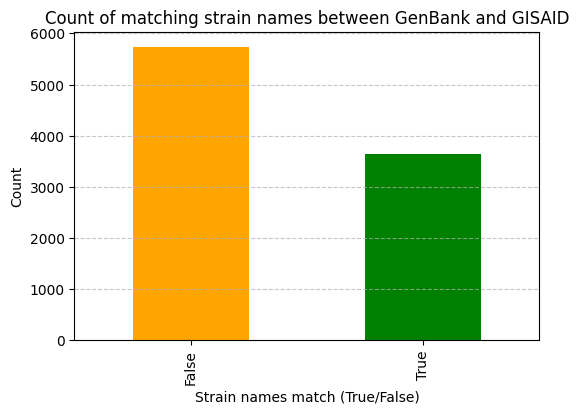

In [ ]:
genbank_gisaid_common[genbank_gisaid_common["Isolate_Name_genbank"] != genbank_gisaid_common["Isolate_Name_gisaid"]][["Isolate_Name_genbank", "Isolate_Name_gisaid"]]

matches = (genbank_gisaid_common["Isolate_Name_genbank"] == genbank_gisaid_common["Isolate_Name_gisaid"])

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
match_counts.plot(kind='bar', color=['orange', 'green'])

# Adding labels and a title
plt.title('Count of matching strain names between GenBank and GISAID')
plt.xlabel('Strain names match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### Collection Dates

All of these share isolate IDs, but have different collection dates in the metadata. This occurs in (117/4955) entries of our sample.

Date discrepancy examples:
- GISAID sometimes changes the collection date to the beginning of the month (2022-12-26 -> 12-01-2022, etc.)
- GISAID sometimes changes the collection date to a completely different date (2024-03-08 -> 2024-02-26, etc.)
- GISAID sometimes changes the collection date, if unknown and year 2025-2026, to the first of the year (2025 -> 2025-01-01, etc.) (Not in this sample)

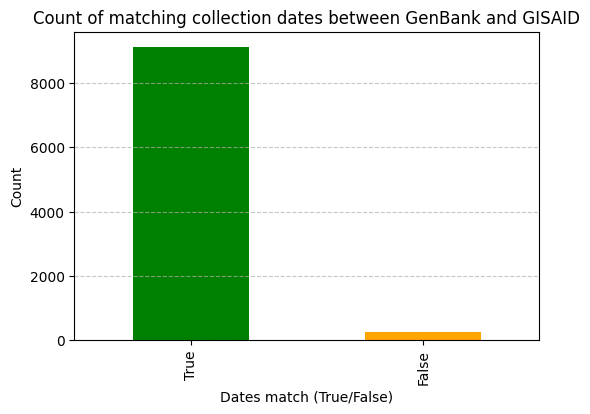

In [ ]:
genbank_gisaid_common[genbank_gisaid_common["Collection_Date_gisaid"] != genbank_gisaid_common["Collection_Date_genbank"]][["Isolate_Name_genbank", "Isolate_Name_gisaid", "Isolate", "Collection_Date_genbank", "Collection_Date_gisaid"]]

matches = (genbank_gisaid_common["Collection_Date_genbank"] == genbank_gisaid_common["Collection_Date_gisaid"])

match_counts = matches.value_counts()

plt.figure(figsize=(6, 4))

# Plotting the match counts
match_counts.plot(kind='bar', color=['green', 'orange'])

# Adding labels and a title
plt.title('Count of matching collection dates between GenBank and GISAID')
plt.xlabel('Dates match (True/False)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

### Host Names

All of these share isolate IDs, but have different host names in the metadata. This occurs in the **majority** (4811/4955) of our sample, though much of this can be explained by GISAID opting for the common name over the scientific name of each species.

Host name discrepancy examples:
- GISAID often just has the word "Host" in place of a host name (Leucophaeus modestus/gray gull -> Host)
- GISAID often, instead of using the specific species, has the host type in place of a host name (Theristicus caudatus/buff-necked ibis -> Avian)

In [ ]:
genbank_gisaid_common[genbank_gisaid_common["Host_gisaid"] != genbank_gisaid_common["Host_genbank"]][["Isolate_Name_genbank", "Isolate_Name_gisaid", "Isolate", "Host_genbank", "Host_gisaid"]]

,Isolate_Name_genbank,Isolate_Name_gisaid,Isolate,Host_genbank,Host_gisaid
55,A/American pelican/Kansas/W22-200/2022,A/American pelican/Kansas/W22-200/2022,W22-200,Pelecanus erythrorhynchos,Host
56,A/American pelican/Kansas/W22-200/2022,A/American pelican/Kansas/W22-200/2022,W22-200,Pelecanus erythrorhynchos,Host
57,A/American pelican/Kansas/W22-200/2022,A/American pelican/Kansas/W22-200/2022,W22-200,Pelecanus erythrorhynchos,Host
58,A/American pelican/Kansas/W22-200/2022,A/American pelican/Kansas/W22-200/2022,W22-200,Pelecanus erythrorhynchos,Host
59,A/American pelican/Kansas/W22-200/2022,A/American pelican/Kansas/W22-200/2022,W22-200,Pelecanus erythrorhynchos,Host
...,...,...,...,...,...
9372,A/Louisiana/12/2024 Original,A/Louisiana/12/2024,12,Homo sapiens,Human
9373,A/Louisiana/12/2024 Original,A/Louisiana/12/2024,12,Homo sapiens,Human
9374,A/Louisiana/12/2024 Original,A/Louisiana/12/2024,12,Homo sapiens,Human
9375,A/Louisiana/12/2024 Original,A/Louisiana/12/2024,12,Homo sapiens,Human


### Locations

In [ ]:
# print(genbank_gisaid_common[genbank_gisaid_common["Geo_Location_Specific_gisaid"] != genbank_gisaid_common["Geo_Location_Specific_genbank"]][["Isolate_Name_genbank", "Isolate_Name_gisaid", "Isolate", "Geo_Location_Specific_genbank", "Geo_Location_Specific_gisaid"]])
print(genbank_gisaid_common[(genbank_gisaid_common["Geo_Location_Specific_gisaid"] != genbank_gisaid_common["USA"]) & (genbank_gisaid_common["Country"] == "USA")][["Isolate_Name_genbank", "Isolate_Name_gisaid", "Isolate", "Geo_Location_Specific_genbank", "Geo_Location_Specific_gisaid"]])

                  Isolate_Name_genbank               Isolate_Name_gisaid  \
0     A/bald eagle/Kansas/W22-197/2022  A/bald eagle/Kansas/W22-197/2022   
1     A/bald eagle/Kansas/W22-197/2022  A/bald eagle/Kansas/W22-197/2022   
2     A/bald eagle/Kansas/W22-197/2022  A/bald eagle/Kansas/W22-197/2022   
3     A/bald eagle/Kansas/W22-197/2022  A/bald eagle/Kansas/W22-197/2022   
4     A/bald eagle/Kansas/W22-197/2022  A/bald eagle/Kansas/W22-197/2022   
...                                ...                               ...   
9372      A/Louisiana/12/2024 Original               A/Louisiana/12/2024   
9373      A/Louisiana/12/2024 Original               A/Louisiana/12/2024   
9374      A/Louisiana/12/2024 Original               A/Louisiana/12/2024   
9375      A/Louisiana/12/2024 Original               A/Louisiana/12/2024   
9376      A/Louisiana/12/2024 Original               A/Louisiana/12/2024   

      Isolate Geo_Location_Specific_genbank Geo_Location_Specific_gisaid  
0     W22-19

## GISAID Metadata Updates

Sometimes, GISAID silently updates or changes metadata without warning.

GISAID metadata change examples:
- Sometimes GISAID appends or removes the last two digits of the year to the isolate ID, changing the strain name altogether (24_035820-001 -> 024710-001)
    - The last two digits of the year may be appended with an underscore, or a hyphen, making parsing the "root" isolate ID difficult (24-000001-001 vs. 24_000001-001)
    - Some isolate IDs include an "-original" appendage, making de-duplication between databases difficult (24-000001-001-original vs. 24-000001-001)
    - Some isolate IDs include an "-R2" or "-repeat2" appendage, making de-duplication between databases difficult (24-000001-001-R2 or 24-000001-001-original-repeat2 vs. 24-000001-001)
- Sometimes dates change completely without warning (2024-02-27 -> 2024-08-26)
- Sometimes dates are egregiously incorrect, both in the isolate name and the metadata, and must be updated later (A/bald eagle/Alaska/22-035250-002/1905, 1905-07-14 -> A/bald eagle/Alaska/22-035250-002/2022, 2022-02-27) 
- Genotypes may change without warning, or a genotype may be changed from an assigned to genotype to "Not assigned", even when the genotype is still current (B3.13 -> Notassigned)
    - Genotypes disappear in (135/6385) entries in our sample.
    - Rarely will a genotype be updated from "Not assigned" to an assigned genotype
- There is no mechanism in GISAID to know when metadata is updated -- meaning that all data must be downloaded each time just in case metadata (or the strain name altogether) has changed (A/dairy cow/USA/24_024710-001/2024 -> A/dairy cow/California/024710-001/2024)
    - While an "update date" column exists in the metadata, it mostly seems to only match the submission date -- otherwise, the update is either unclear or a removal of a previously assigned genotype without a replacement (B3.2 -> Notassigned)

In [ ]:
print(gisaid_time[gisaid_time["Isolate_old"] != gisaid_time["Isolate_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new"]])

                        Isolate_Name_old  \
7560  A/dairy cow/USA/24_030591-001/2024   
7561  A/dairy cow/USA/24_030592-002/2024   
7589  A/dairy cow/USA/24_030166-001/2024   
7604  A/dairy cow/USA/24_031290-001/2024   
7605  A/dairy cow/USA/24_031293-001/2024   
...                                  ...   
9925  A/dairy cow/USA/24_034429-001/2024   
9931  A/dairy cow/USA/24_034654-001/2024   
9937  A/dairy cow/USA/24_034694-001/2024   
9938  A/dairy cow/USA/24_034694-003/2024   
9939  A/dairy cow/USA/24_034695-001/2024   

                            Isolate_Name_new    Isolate_old Isolate_new  
7560  A/dairy cow/California/030591-001/2024  24_030591-001  030591-001  
7561  A/dairy cow/California/030592-002/2024  24_030592-002  030592-002  
7589  A/dairy cow/California/030166-001/2024  24_030166-001  030166-001  
7604  A/dairy cow/California/031290-001/2024  24_031290-001  031290-001  
7605  A/dairy cow/California/031293-001/2024  24_031293-001  031293-001  
...                        

In [ ]:
print(gisaid_time[gisaid_time["Isolate_Name_old"] != gisaid_time["Isolate_Name_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new", "Collection_Date_old", "Collection_Date_new"]])

                               Isolate_Name_old  \
5510  A/glaucous gull/Alaska/22-023553-003/1905   
5513  A/glaucous gull/Alaska/22-031916-001/1905   
5764    A/black brant/Alaska/22-023553-002/1905   
5964     A/bald eagle/Alaska/22-035250-001/1905   
5965     A/bald eagle/Alaska/22-035250-002/1905   
...                                         ...   
9925         A/dairy cow/USA/24_034429-001/2024   
9931         A/dairy cow/USA/24_034654-001/2024   
9937         A/dairy cow/USA/24_034694-001/2024   
9938         A/dairy cow/USA/24_034694-003/2024   
9939         A/dairy cow/USA/24_034695-001/2024   

                               Isolate_Name_new    Isolate_old    Isolate_new  \
5510  A/glaucous gull/Alaska/22-023553-003/2022  22-023553-003  22-023553-003   
5513  A/glaucous gull/Alaska/22-031916-001/2022  22-031916-001  22-031916-001   
5764    A/black brant/Alaska/22-023553-002/2022  22-023553-002  22-023553-002   
5964     A/bald eagle/Alaska/22-035250-001/2022  22-035250-001 

In [ ]:
print(gisaid_time[gisaid_time["Collection_Date_old"] != gisaid_time["Collection_Date_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new", "Collection_Date_old", "Collection_Date_new"]])

                               Isolate_Name_old  \
5510  A/glaucous gull/Alaska/22-023553-003/1905   
5513  A/glaucous gull/Alaska/22-031916-001/1905   
5764    A/black brant/Alaska/22-023553-002/1905   
5964     A/bald eagle/Alaska/22-035250-001/1905   
5965     A/bald eagle/Alaska/22-035250-002/1905   
7561         A/dairy cow/USA/24_030592-002/2024   
7589         A/dairy cow/USA/24_030166-001/2024   
7605         A/dairy cow/USA/24_031293-001/2024   
7610         A/dairy cow/USA/24_030088-001/2024   
7627         A/dairy cow/USA/24_029902-001/2024   
7639         A/dairy cow/USA/24_029895-001/2024   
8147         A/dairy cow/USA/24_029610-001/2024   
9367         A/dairy cow/USA/24_033851-001/2024   
9403         A/dairy cow/USA/24_034231-001/2024   
9404         A/dairy cow/USA/24_034231-002/2024   
9405         A/dairy cow/USA/24_034231-003/2024   
9447         A/dairy cow/USA/24_033991-001/2024   
9448         A/dairy cow/USA/24_033991-002/2024   
9449         A/dairy cow/USA/24

In [ ]:
print(gisaid_time[gisaid_time["Location_old"] != gisaid_time["Location_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new","Location_old", "Location_new"]])

                                     Isolate_Name_old  \
694                     A/Pelican/Venezuela/Pel4/2022   
695                     A/Pelican/Venezuela/Pel3/2022   
862     A/Pelecanus occidentalis/Venezuela/Inf13/2022   
1101                    A/Pelican/Venezuela/Inf9/2022   
4144  A/Pelecanus occidentalis/Venezuela/Inf1/2022 \t   
4145    A/Pelecanus occidentalis/Venezuela/Inf14/2022   
4146    A/Pelecanus occidentalis/Venezuela/Inf19/2022   
4147    A/Pelecanus occidentalis/Venezuela/Inf20/2022   
4148    A/Pelecanus occidentalis/Venezuela/Inf41/2023   
4149    A/Pelecanus occidentalis/Venezuela/Inf44/2023   
7561               A/dairy cow/USA/24_030592-002/2024   
7589               A/dairy cow/USA/24_030166-001/2024   
7605               A/dairy cow/USA/24_031293-001/2024   
7610               A/dairy cow/USA/24_030088-001/2024   
7627               A/dairy cow/USA/24_029902-001/2024   
7639               A/dairy cow/USA/24_029895-001/2024   
8147               A/dairy cow/

In [ ]:
print(gisaid_time[gisaid_time["Genotype_old"] != gisaid_time["Genotype_new"]][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new","Genotype_old", "Genotype_new"]])
print(gisaid_time[(gisaid_time["Genotype_old"] != gisaid_time["Genotype_new"]) & (gisaid_time["Genotype_new"].str.contains("Notassigned"))][["Isolate_Name_old", "Isolate_Name_new", "Isolate_old", "Isolate_new","Genotype_old", "Genotype_new"]])

                                        Isolate_Name_old  \
689               A/Great Horned Owl/AB/FAV-0505-52/2022   
692                           A/RT-Hawk/ON/FAV-0210/2022   
720                        A/Chicken/AB/FAV-0438-02/2022   
722                        A/Chicken/ON/FAV-0217-05/2022   
723                       A/Chicken/ON/FAV-0208-144/2022   
...                                                  ...   
12060                      A/chicken/USA/033249-004/2024   
12063                      A/chicken/USA/033249-006/2024   
12074  A/white-winged scoter/Massachusetts/007609-002...   
12075  A/white-winged scoter/Massachusetts/007609-003...   
12086         A/bald eagle/Massachusetts/007606-010/2024   

                                        Isolate_Name_new   Isolate_old  \
689               A/Great Horned Owl/AB/FAV-0505-52/2022   FAV-0505-52   
692                           A/RT-Hawk/ON/FAV-0210/2022      FAV-0210   
720                        A/Chicken/AB/FAV-0438-02/2022 

In [ ]:
print(gisaid_time[gisaid_time["Update_Date_old"] != gisaid_time["Update_Date_new"]][["Isolate_Name_old", "Isolate_Name_new", "Update_Date_old", "Update_Date_new"]]) # All NaN


                                 Isolate_Name_old  \
7                A/snow goose/Kansas/W22-260/2022   
9           A/snow goose/North Dakota/N22-05/2022   
12              A/snow goose/Kansas/W22-199C/2022   
13              A/snow goose/Kansas/W22-199E/2022   
14              A/snow goose/Kansas/W22-199B/2022   
...                                           ...   
12087  A/bald eagle/Massachusetts/014126-048/2024   
12088       A/bald eagle/Virginia/014128-001/2024   
12089  A/bald eagle/Massachusetts/014126-004/2024   
12090  A/bald eagle/Massachusetts/014126-005/2024   
12091  A/bald eagle/Massachusetts/014126-007/2024   

                                 Isolate_Name_new Update_Date_old  \
7                A/snow goose/Kansas/W22-260/2022             NaN   
9           A/snow goose/North Dakota/N22-05/2022             NaN   
12              A/snow goose/Kansas/W22-199C/2022             NaN   
13              A/snow goose/Kansas/W22-199E/2022             NaN   
14              A/

In [ ]:
print(gisaid_time[(gisaid_time["Update_Date_old"] != gisaid_time["Submission_Date_old"]) & (gisaid_time["Update_Date_old"] == gisaid_time["Update_Date_old"])][["Isolate_Name_old", "Isolate_Name_new", "Update_Date_old", "Submission_Date_old", "Collection_Date_old", "Collection_Date_new", "Location_old", "Location_new", "Genotype_old", "Genotype_new", "Host_old", "Host_new"]])

                                    Isolate_Name_old  \
0                   A/goose/Idaho/22-012047-001/2022   
5                  A/snow goose/Kansas/W22-174B/2022   
6        A/lesser snow goose/North Dakota/ND-10/2022   
8                  A/snow goose/Kansas/W22-177B/2022   
10             A/snow goose/North Dakota/N22-04/2022   
...                                              ...   
8992                  A/Chicken/BC/FAV-0289-002/2024   
9111   A/kelp_gull/South Shetland Islands/10272/2024   
9803                A/British_Columbia/PHL-2032/2024   
10692                            A/Louisiana/12/2024   
10693                            A/Louisiana/12/2024   

                                  Isolate_Name_new Update_Date_old  \
0                 A/goose/Idaho/22-012047-001/2022      2022-12-18   
5                A/snow goose/Kansas/W22-174B/2022      2022-09-12   
6      A/lesser snow goose/North Dakota/ND-10/2022      2022-09-12   
8                A/snow goose/Kansas/W22-177B/2